<a href="https://colab.research.google.com/github/Areeba-collab/ai-ml-journey/blob/main/seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import seaborn as sns
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='sex', ylabel='total_bill'>

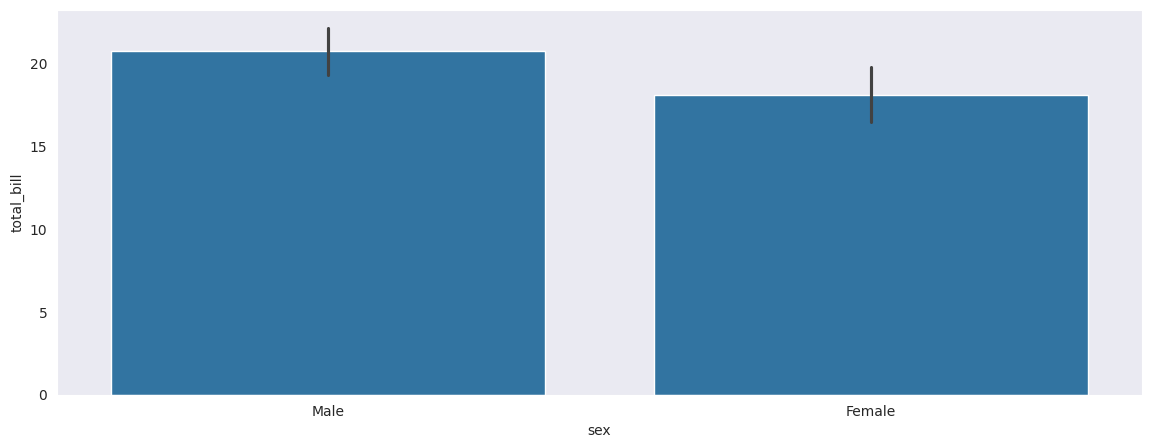

In [18]:
plt.figure(figsize=(14,5))
sns.set_style("dark")
sns.barplot(data = tips , x = "sex" , y = "total_bill")

In [ ]:
print(tips['sex'].unique())

['Female', 'Male']
Categories (2, object): ['Male', 'Female']


<Axes: xlabel='total_bill', ylabel='Count'>

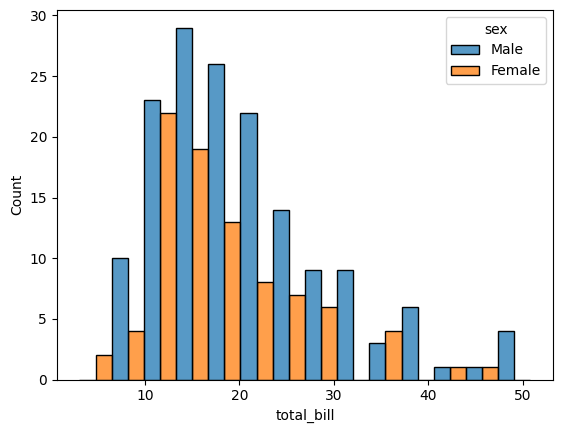

In [ ]:
sns.histplot(data=tips, x="total_bill", hue="sex", multiple="dodge")

### Correlation Matrix and Heatmap

First, let's look at the correlations between numerical features in the dataset and visualize them using a heatmap.

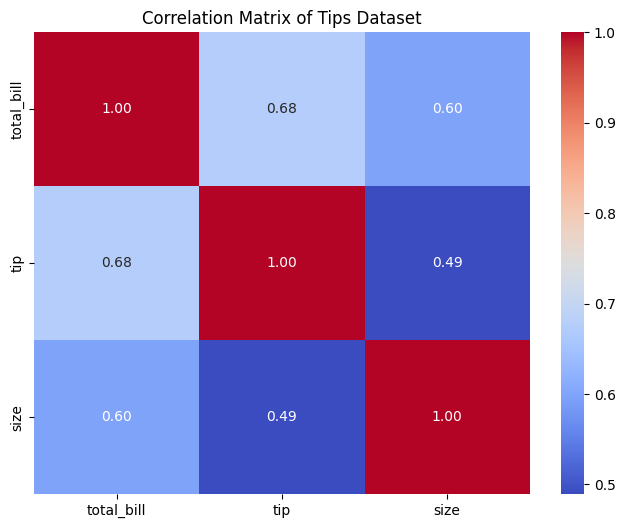

In [4]:
import matplotlib.pyplot as plt

# Select only numerical columns for correlation calculation
numerical_tips = tips.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_tips.corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Tips Dataset')
plt.show()

This **heatmap** visualizes the correlation matrix of the numerical features (`total_bill`, `tip`, `size`) in the `tips` dataset.

*   **Color intensity and values**: Darker colors (closer to red) indicate a stronger positive correlation, while lighter colors (closer to blue) would indicate a negative correlation. The numbers inside each cell represent the correlation coefficient.
*   **Key observations**:
    *   `total_bill` and `tip` have a strong positive correlation (0.68), meaning that as the total bill increases, the tip amount tends to increase as well.
    *   `total_bill` and `size` (party size) also show a positive correlation (0.60), suggesting larger parties tend to have larger total bills.
    *   `tip` and `size` have a moderate positive correlation (0.49), indicating that larger parties might also leave higher tips, which is reasonable given the higher total bill.

### Distributions of Numerical Variables

Next, let's visualize the distribution of key numerical variables like `total_bill` and `tip`.

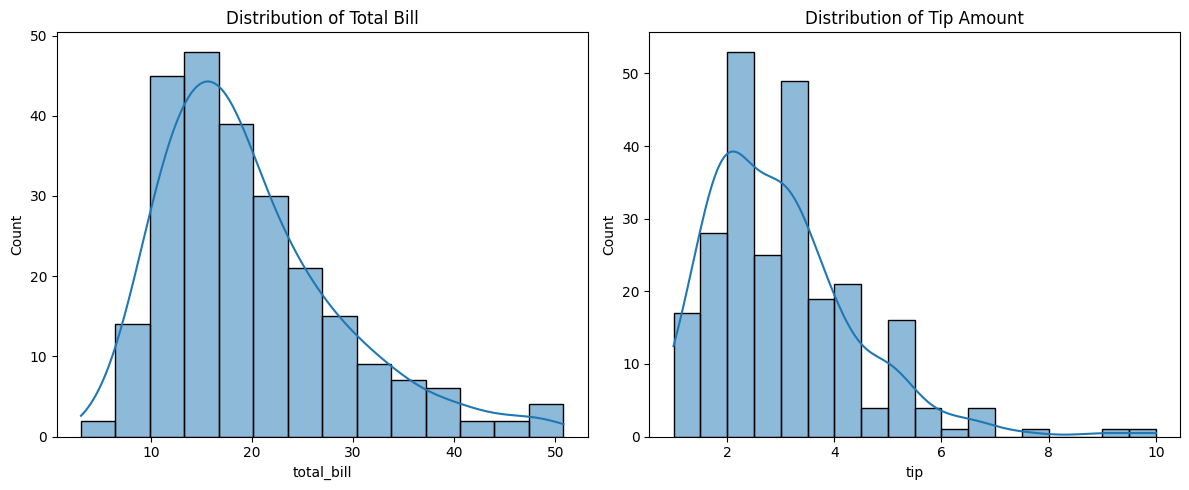

In [5]:
# Distribution of 'total_bill'
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(tips['total_bill'], kde=True)
plt.title('Distribution of Total Bill')

# Distribution of 'tip'
plt.subplot(1, 2, 2)
sns.histplot(tips['tip'], kde=True)
plt.title('Distribution of Tip Amount')

plt.tight_layout()
plt.show()

These **histograms** show the distribution of two key numerical variables:

*   **Distribution of Total Bill**: Most `total_bill` values fall between $10 and $25, with a peak around $15-$20. The distribution is right-skewed, indicating that while most bills are smaller, there are a few considerably larger bills.
*   **Distribution of Tip Amount**: The majority of tips are between $1 and $4, with a peak around $2-$3. Similar to the total bill, the tip distribution is also right-skewed, suggesting that most tips are relatively small, but some larger tips are given.

### Relationships Between Variables

Now, let's explore relationships between different variables, including numerical and categorical ones.

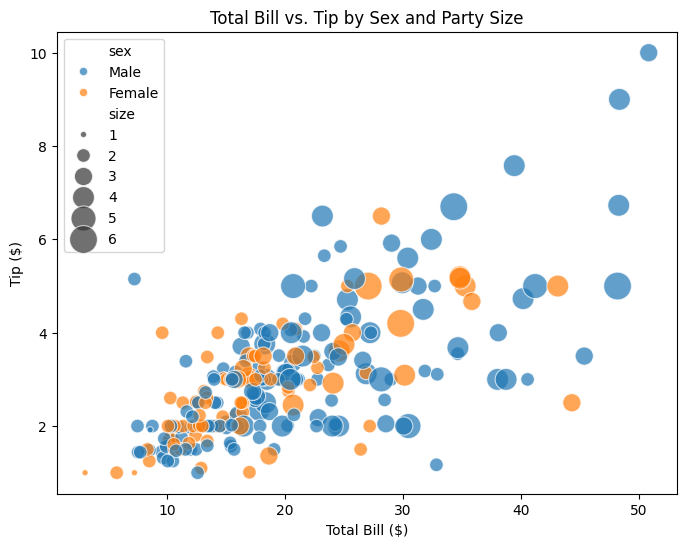

In [6]:
# Relationship between Total Bill and Tip
plt.figure(figsize=(8, 6))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex', size='size', sizes=(20, 400), alpha=0.7)
plt.title('Total Bill vs. Tip by Sex and Party Size')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.show()

This **scatter plot** explores the relationship between `total_bill` and `tip`, with additional insights provided by `sex` (color) and `size` (point size).

*   **Positive Relationship**: As observed in the correlation matrix, there's a clear positive linear trend: higher total bills generally correspond to higher tip amounts.
*   **Sex**: The colors (blue for Male, orange for Female) show that both male and female customers follow a similar trend in tipping relative to the total bill. There isn't a strikingly different tipping pattern between sexes based on the bill amount.
*   **Party Size (`size`)**: Larger points represent larger party sizes. It appears that larger parties tend to be associated with both higher total bills and, consequently, higher tips. This reinforces the positive correlation seen earlier between `size` and both `total_bill` and `tip`.

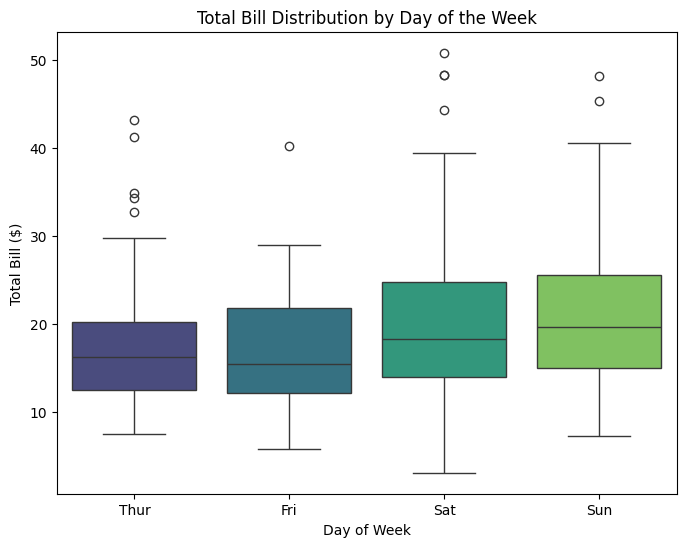

In [9]:
# Box plot of Total Bill by Day
plt.figure(figsize=(8, 6))
sns.boxplot(data=tips, x='day', y='total_bill', hue='day', palette='viridis', legend=False)
plt.title('Total Bill Distribution by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Bill ($)')
plt.show()

This **box plot** illustrates the distribution of `total_bill` across different days of the week (`Thur`, `Fri`, `Sat`, `Sun`).

*   **Median Bill**: The white line inside each box represents the median `total_bill` for that day.
*   **Interquartile Range (IQR)**: The box itself spans the first quartile (Q1) to the third quartile (Q3), representing the middle 50% of the data.
*   **Whiskers**: The lines extending from the box (whiskers) typically show the range of data within 1.5 times the IQR from Q1 and Q3.
*   **Outliers**: Points beyond the whiskers are considered outliers.
*   **Key observations**:
    *   **Saturday (Sat)** and **Sunday (Sun)** generally have higher median total bills and a wider spread, indicating more expensive meals and a greater variety of bill amounts on weekends.
    *   **Thursday (Thur)** has a lower median and a tighter distribution compared to the weekend, suggesting more consistent and generally lower bills.
    *   **Friday (Fri)** shows a distribution somewhat in between weekdays and weekends, with a moderate median and spread.

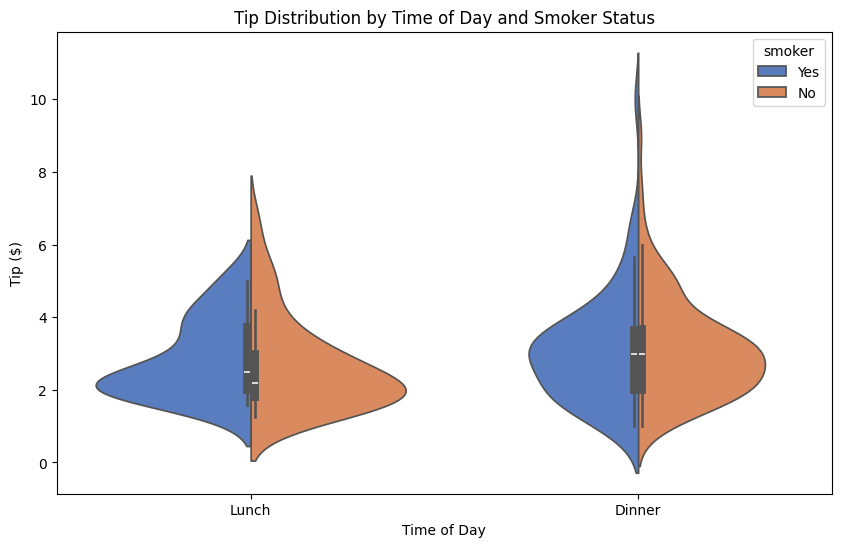

In [8]:
# Violin plot of Tip by Time and Smoker status
plt.figure(figsize=(10, 6))
sns.violinplot(data=tips, x='time', y='tip', hue='smoker', split=True, palette='muted')
plt.title('Tip Distribution by Time of Day and Smoker Status')
plt.xlabel('Time of Day')
plt.ylabel('Tip ($)')
plt.show()

This **violin plot** displays the distribution of `tip` amounts, segmented by `time` (Dinner/Lunch) and `smoker` status (Yes/No). Violin plots combine aspects of box plots and kernel density plots, showing the distribution shape.

*   **Overall Tip Distribution**: The 'violins' show the density of tip amounts. Wider sections indicate more data points at that tip value.
*   **Time of Day**:
    *   **Dinner** generally has a wider distribution for tips, suggesting a greater range of tip amounts, and potentially higher tips overall, compared to Lunch.
    *   **Lunch** tips appear to be concentrated at lower values.
*   **Smoker Status (`hue='smoker'`, `split=True`)**:
    *   The `split=True` parameter allows comparing the distributions of smokers and non-smokers within each time category.
    *   For **Dinner**, the tip distributions for smokers and non-smokers seem fairly similar, although non-smokers might have a slightly higher density at certain tip values.
    *   For **Lunch**, non-smokers appear to have a slightly higher concentration of tips at lower values compared to smokers.

This plot helps to understand how the amount of tip varies not just by time of day but also by whether the customer is a smoker.